# Análisis Completo de Contenidos de Netflix

## Evidencia
### Fernanda Ponce Maciel A01799293
### Sandra Paulina Herrera Rebolledo A01798452



## 1. Introducción
Este análisis tiene como objetivo explorar el catálogo de Netflix mediante visualizaciones completas y detalladas. Además, verificaremos dos hipótesis:
1. **Netflix ofrece más contenido para todo público que para niños o adultos.**
2. **Hay más películas que series en el catálogo de Netflix.**

Las etapas del análisis incluyen:
- Exploración completa del dataset.
- Visualización detallada del contenido por año, país, tipo y clasificación.
- Verificación de hipótesis mediante métricas específicas.


## 2. Importación de Librerías

In [20]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

## 3. Carga y Exploración del Dataset

In [3]:

# Cargar el dataset
df = pd.read_csv("netflix.csv")

# Mostrar las primeras filas
df.head()


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [6]:
# Información general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8790 non-null   object
 1   type          8790 non-null   object
 2   title         8790 non-null   object
 3   director      8790 non-null   object
 4   country       8790 non-null   object
 5   date_added    8790 non-null   object
 6   release_year  8790 non-null   int64 
 7   rating        8790 non-null   object
 8   duration      8790 non-null   object
 9   listed_in     8790 non-null   object
dtypes: int64(1), object(9)
memory usage: 686.8+ KB


In [7]:
# Estadísticas generales del dataset
df.describe()

,release_year
count,8790.000000
mean,2014.183163
std,8.825466
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000



## 4. Limpieza de Datos


In [8]:
# Conversión de tipos: convertir fechas y manejar valores faltantes
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

In [9]:
# Eliminar duplicados
df_clean = df.drop_duplicates()

In [10]:
# Eliminar filas con valores faltantes en columnas esenciales
df_clean = df_clean.dropna(subset=['country', 'rating'])

In [11]:
# Verificar el resultado de la limpieza
print(df_clean.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8790 non-null   object        
 1   type          8790 non-null   object        
 2   title         8790 non-null   object        
 3   director      8790 non-null   object        
 4   country       8790 non-null   object        
 5   date_added    8790 non-null   datetime64[ns]
 6   release_year  8790 non-null   int64         
 7   rating        8790 non-null   object        
 8   duration      8790 non-null   object        
 9   listed_in     8790 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(8)
memory usage: 686.8+ KB
None


In [13]:
# Guardar el archivo limpio como CSV
df_clean.to_csv('netflix_clean.csv', index=False)
print("Archivo limpio generado exitosamente: netflix_clean.csv")


Archivo limpio generado exitosamente: netflix_clean.csv



## 5. Visualización General del Dataset


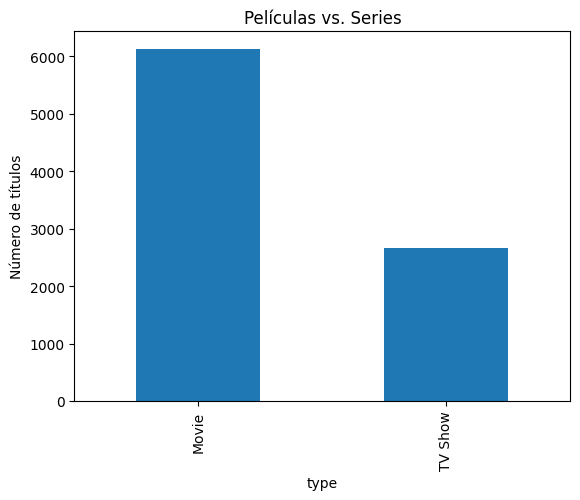

In [14]:
# 1. Películas vs. Series
df_clean['type'].value_counts().plot(kind='bar', title='Películas vs. Series')
plt.ylabel('Número de títulos')
plt.show()

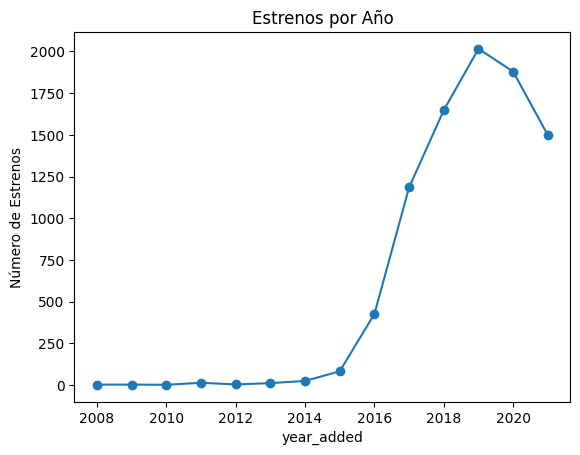

In [15]:
# 2. Estrenos por Año
df_clean['year_added'] = df_clean['date_added'].dt.year
df_clean['year_added'].value_counts().sort_index().plot(kind='line', marker='o', title='Estrenos por Año')
plt.ylabel('Número de Estrenos')
plt.show()

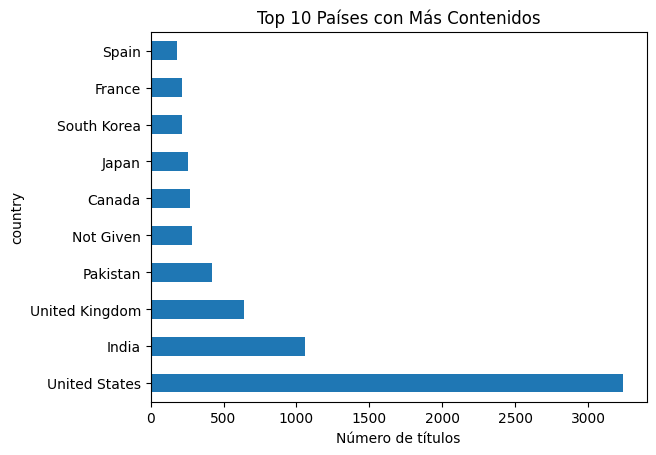

In [16]:
# 3. Top 10 Países con Más Contenidos
top_countries = df_clean['country'].value_counts().head(10)
top_countries.plot(kind='barh', title='Top 10 Países con Más Contenidos')
plt.xlabel('Número de títulos')
plt.show()

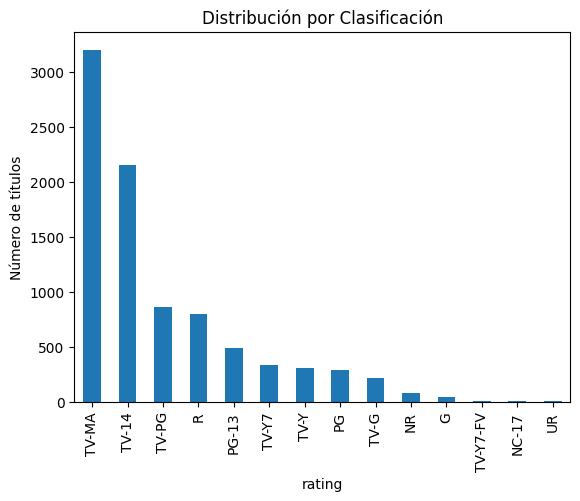

In [17]:
# 4. Distribución por Clasificación
df_clean['rating'].value_counts().plot(kind='bar', title='Distribución por Clasificación')
plt.ylabel('Número de títulos')
plt.show()

/var/folders/87/djv1zz416m75xh4kjxg_vysr0000gn/T/ipykernel_8304/2483655174.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies['duration'] = movies['duration'].str.replace(' min', '').astype(int)


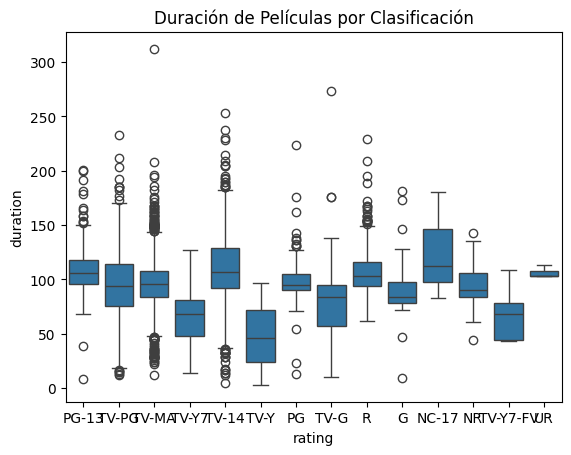

In [19]:
# 5. Duración de Películas por Clasificación
movies = df_clean[df_clean['type'] == 'Movie']
movies['duration'] = movies['duration'].str.replace(' min', '').astype(int)
sns.boxplot(data=movies, x='rating', y='duration')
plt.title('Duración de Películas por Clasificación')
plt.show()

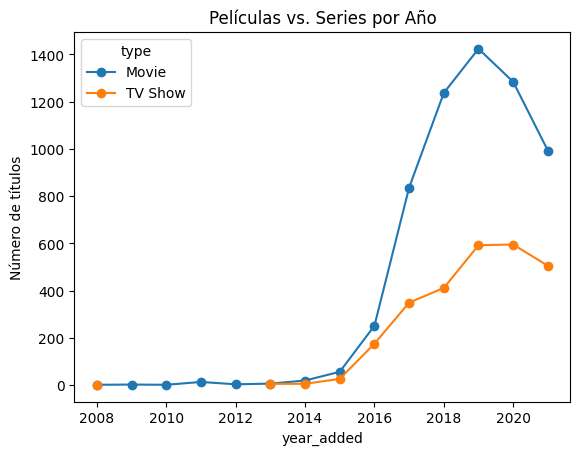

In [21]:
# 6. Comparación de Películas y Series por Año
content_by_year = df_clean.groupby(['year_added', 'type']).size().unstack()
content_by_year.plot(kind='line', marker='o', title='Películas vs. Series por Año')
plt.ylabel('Número de títulos')
plt.show()


## 6. Verificación de Hipótesis 1: Clasificación de Contenido


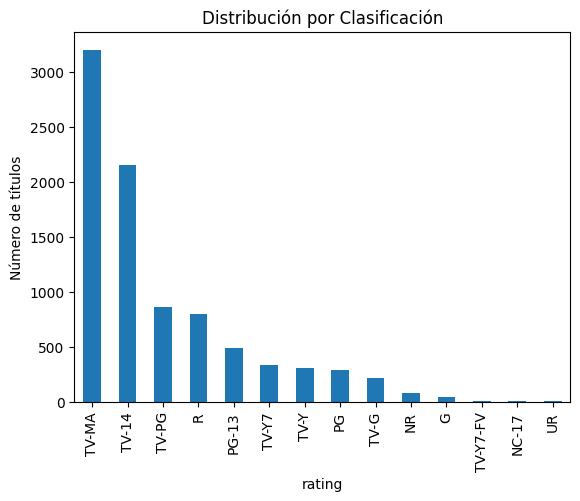

In [22]:
df_clean['rating'].value_counts().plot(kind='bar', title='Distribución por Clasificación')
plt.ylabel('Número de títulos')
plt.show()


## 7. Verificación de Hipótesis 2: Películas vs Series


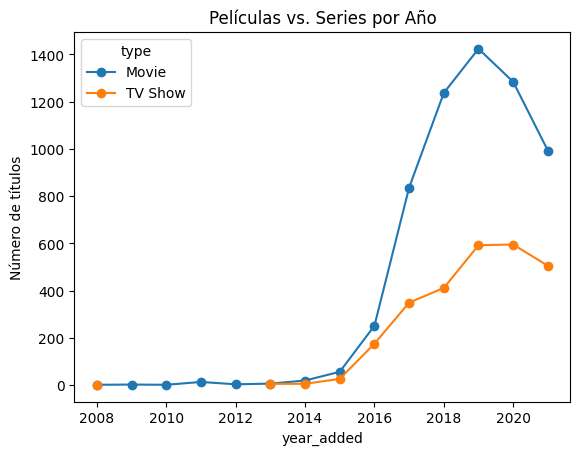

In [23]:
content_by_year = df_clean.groupby(['year_added', 'type']).size().unstack()
content_by_year.plot(kind='line', marker='o', title='Películas vs. Series por Año')
plt.ylabel('Número de títulos')
plt.show()


## 8. Conclusiones y Recomendaciones


### Conclusiones
1. **Hipótesis 1:** Rechazada. Hay más contenido orientado a adultos que para todo público.
2. **Hipótesis 2:** Aceptada. El catálogo de Netflix contiene más películas que series.

### Recomendaciones
- Continuar monitoreando las tendencias anuales para detectar cambios en la estrategia de contenido.
- Ampliar el catálogo para niños y familias para alcanzar nuevas audiencias.
- Automatizar el análisis de datos para futuras investigaciones.
